In [1]:
from pathlib import Path

import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score  # классы несбалансированы
from sklearn.metrics import average_precision_score  # положительный класс -- редкий
from sklearn.metrics import balanced_accuracy_score  # accuracy для дисбаланса
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve

import optuna

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_DIR = Path("/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
submit_path = DATA_DIR / "submit.csv"

for path in [train_path, test_path, submit_path]:
    print(f"{path}:", "OK" if path.exists() else "NOT FOUND")

/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/train.csv: OK
/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/test.csv: OK
/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/submit.csv: OK


In [4]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
submit_df = pd.read_csv(submit_path)

df = train_df.copy()

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("submit shape:", submit_df.shape)

train shape: (247972, 1369)
test shape: (106274, 1368)
submit shape: (106274, 2)


In [5]:
df.head()

,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
0,239134,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,1,1,1,1,1,0
1,234708,0.0,0.5,0.5,1.0,1.0,0.0,0.0,0.0,1.0,...,-1.0,-1.0,-1.0,1,1,1,1,0,0,1
2,268300,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,4.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
3,283077,0.0,0.5,0.5,1.0,1.0,1.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0
4,337271,1.0,0.5,0.5,1.0,1.0,1.0,9.0,1.0,1.0,...,0.0,0.0,0.0,0,0,0,0,0,0,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 247972 entries, 0 to 247971
Columns: 1369 entries, index to feature_1366
dtypes: float64(1361), int64(8)
memory usage: 2.5 GB


In [7]:
df.describe()

,index,target,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_1357,feature_1358,feature_1359,feature_1360,feature_1361,feature_1362,feature_1363,feature_1364,feature_1365,feature_1366
count,247972.000000,247972.000000,247972.0,247972.0,247972.0,247972.0,247972.000000,247972.000000,247972.000000,247972.000000,...,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000,247972.000000
mean,177081.186364,0.013493,0.5,0.5,1.0,1.0,0.794473,1.864892,1.270490,1.457911,...,-0.143246,-0.145520,-0.149049,0.121848,0.136741,0.096204,0.034742,0.139403,0.190792,0.149783
std,102245.504744,0.115375,0.0,0.0,0.0,0.0,0.715883,1.802944,0.919966,1.622873,...,0.368512,0.364513,0.358193,0.327111,0.343575,0.294872,0.183126,0.346367,0.392926,0.356859
min,2.000000,0.000000,0.5,0.5,1.0,1.0,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,88544.750000,0.000000,0.5,0.5,1.0,1.0,0.000000,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,177110.500000,0.000000,0.5,0.5,1.0,1.0,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,265596.750000,0.000000,0.5,0.5,1.0,1.0,1.000000,3.000000,2.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,354243.000000,1.000000,0.5,0.5,1.0,1.0,13.000000,30.000000,23.000000,31.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


`test` -- аналогичен, но без `target`.

In [8]:
test_df.shape

(106274, 1368)

In [9]:
feature_cols = [col for col in train_df.columns if col not in ["index", "target"]]

feature_stats = pd.DataFrame(
    {
        "feature_num": [int(col.split("_")[-1]) for col in feature_cols],
        "n_unique": [train_df[col].nunique() for col in feature_cols],
        "n_missing": [train_df[col].isna().sum() for col in feature_cols],
        "top_freq_ratio": [
            train_df[col].value_counts(normalize=True, dropna=False).iloc[0]
            for col in feature_cols
        ],
    }
)

feature_stats = feature_stats.sort_values("feature_num").reset_index(drop=True)

feature_stats.head(5)

,feature_num,n_unique,n_missing,top_freq_ratio
0,0,1,0,1.000000
1,1,1,0,1.000000
2,2,1,0,1.000000
3,3,1,0,1.000000
4,4,13,0,0.532379


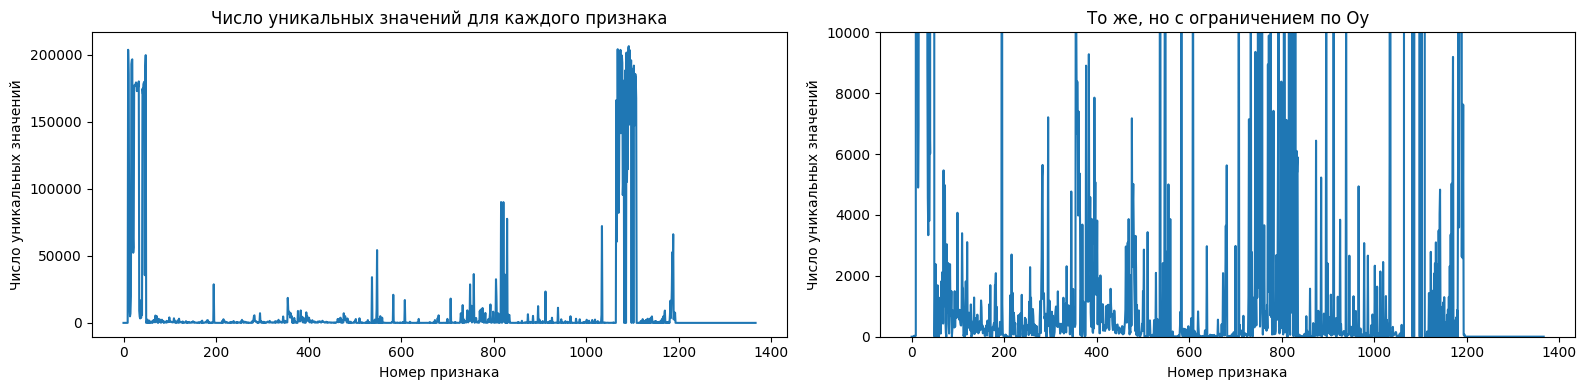

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4), sharey=False)

ax[0].plot(feature_stats["feature_num"], feature_stats["n_unique"])
ax[0].set_xlabel("Номер признака")
ax[0].set_ylabel("Число уникальных значений")
ax[0].set_title("Число уникальных значений для каждого признака")

ax[1].plot(feature_stats["feature_num"], feature_stats["n_unique"])
ax[1].set_xlabel("Номер признака")
ax[1].set_ylabel("Число уникальных значений")
ax[1].set_title("То же, но с ограничением по Oy")
ax[1].set_ylim(0, 10_000)

plt.tight_layout()
plt.show()

### Подготовка данных

In [11]:
train_df = train_df.drop_duplicates()
train_df = train_df.dropna()

for col in train_df.columns:
    if len(train_df.loc[:, col].unique()) < 2:
        print("dropped", col)

        train_df = train_df.drop(columns=[col])

dropped feature_0
dropped feature_1
dropped feature_2
dropped feature_3
dropped feature_49
dropped feature_1057
dropped feature_1064


In [12]:
train_df.shape, train_df.head()

((247972, 1362),
     index  target  feature_4  feature_5  feature_6  feature_7  feature_8  \
 0  239134     0.0        0.0        0.0        0.0        0.0        1.0   
 1  234708     0.0        0.0        0.0        0.0        1.0        0.0   
 2  268300     0.0        1.0        3.0        1.0        4.0        0.0   
 3  283077     0.0        1.0        3.0        1.0        0.0        3.0   
 4  337271     1.0        1.0        9.0        1.0        1.0        3.0   
 
    feature_9  feature_10  feature_11  ...  feature_1357  feature_1358  \
 0        1.0    0.680302    0.767927  ...           0.0           0.0   
 1        1.0    0.680302    0.767927  ...          -1.0          -1.0   
 2        9.0    0.794758    2.471037  ...           0.0           0.0   
 3        8.0    0.917668    0.558128  ...           0.0           0.0   
 4       15.0    0.698426    1.205527  ...           0.0           0.0   
 
    feature_1359  feature_1360  feature_1361  feature_1362  feature_1363 

### Подготовка признаков

Без массового перетирания исходных признаков. Для `RandomForest` raw-поля лучше сохранять: деревья и так работают с порогами, а агрессивные `clip/log/median` могут ломать полезный порядок значений и снижать ROC AUC.

Ниже добавляются только дополнительные флаги/копии для явно подозрительных групп признаков.

In [13]:
# === safer feature engineering for ROC AUC / RandomForest ===
# Идея: НЕ уничтожать raw-признаки, а добавлять потенциально полезные флаги/копии рядом.
# Вставлено до формирования X_ / y_, чтобы новые признаки попали в обе модели.

_dfs = [train_df]
if "test_df" in globals():
    _dfs.append(test_df)


def _has(num):
    return f"feature_{num}" in train_df.columns


def _col(num):
    return f"feature_{num}"


# 1) Явный right-cap/spike на правой границе.
# Raw НЕ трогаем. Добавляем только флаг cap-а.
RIGHT_CAP_NUMS = [
    28, 31, 32, 33, 44, 45, 46, 1089,
]

for num in RIGHT_CAP_NUMS:
    if not _has(num):
        continue

    col = _col(num)
    cap_value = train_df[col].max()

    for df_ in _dfs:
        if col in df_.columns:
            df_[f"{col}_is_right_cap"] = (df_[col] >= cap_value).astype("int8")


# 2) Узкий блок, где -1 похож на sentinel/missing.
# ВАЖНО: не трогаем feature_1196..feature_1359 — они выглядят как нормальные ternary -1/0/1.
# Raw НЕ трогаем. Добавляем только флаг -1.
MINUS1_SENTINEL_NUMS = [
    1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116,
    1117, 1118, 1119, 1120, 1121, 1123, 1124,
]

for num in MINUS1_SENTINEL_NUMS:
    if not _has(num):
        continue

    col = _col(num)

    for df_ in _dfs:
        if col in df_.columns:
            df_[f"{col}_is_minus1"] = (df_[col] == -1).astype("int8")


# 3) Positive probability-like признаки.
# Для леса raw оставляем. Log-копия может помочь логрегу и иногда дереву, но не ломает исходный признак.
POSITIVE_LOG_NUMS = [
    1065, 1066, 1067, 1069, 1070, 1071, 1072, 1073,
    1075, 1076, 1077, 1078, 1079, 1080, 1081, 1084,
    1085, 1088, 1090, 1093, 1095, 1096, 1097, 1099,
    1101, 1103, 1105, 1106, 1107,
]

for num in POSITIVE_LOG_NUMS:
    if not _has(num):
        continue

    col = _col(num)
    positive_train = train_df.loc[train_df[col] > 0, col]

    if len(positive_train) == 0:
        continue

    lo = max(positive_train.quantile(0.001), 1e-12)
    hi = max(train_df[col].quantile(0.999), lo)

    for df_ in _dfs:
        if col in df_.columns:
            df_[f"{col}_log"] = np.log(df_[col].clip(lower=lo, upper=hi))


# 4) Доли около [0, 1].
# Raw НЕ трогаем. Добавляем мягкую transform-копию и edge-флаги.
RATIO_01_NUMS = [
    1181, 1182, 1183, 1184, 1185, 1186,
    1187, 1188, 1189, 1190, 1191, 1192,
]

for num in RATIO_01_NUMS:
    if not _has(num):
        continue

    col = _col(num)

    for df_ in _dfs:
        if col in df_.columns:
            x = df_[col].clip(0, 1)
            df_[f"{col}_is_zero"] = (x == 0).astype("int8")
            df_[f"{col}_is_one"] = (x == 1).astype("int8")
            df_[f"{col}_asin_sqrt"] = 2 * np.arcsin(np.sqrt(x))


print("safe feature engineering applied")
print("right cap flags:", len([n for n in RIGHT_CAP_NUMS if _has(n)]))
print("minus1 flags:", len([n for n in MINUS1_SENTINEL_NUMS if _has(n)]))
print("positive log copies:", len([n for n in POSITIVE_LOG_NUMS if _has(n)]))
print("ratio copies:", len([n for n in RATIO_01_NUMS if _has(n)]))
print("train_df shape:", train_df.shape)
if "test_df" in globals():
    print("test_df shape:", test_df.shape)

/var/folders/63/2zwvsfln7r72d2xrnzk1cndc0000gn/T/ipykernel_9683/1458498005.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_[f"{col}_is_right_cap"] = (df_[col] >= cap_value).astype("int8")
/var/folders/63/2zwvsfln7r72d2xrnzk1cndc0000gn/T/ipykernel_9683/1458498005.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_[f"{col}_is_right_cap"] = (df_[col] >= cap_value).astype("int8")
/var/folders/63/2zwvsfln7r72d2xrnzk1cndc0000gn/T/ipykernel_9683/1458498005.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is

safe feature engineering applied
right cap flags: 8
minus1 flags: 15
positive log copies: 29
ratio copies: 12
train_df shape: (247972, 1450)
test_df shape: (106274, 1456)


/var/folders/63/2zwvsfln7r72d2xrnzk1cndc0000gn/T/ipykernel_9683/1458498005.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_[f"{col}_is_zero"] = (x == 0).astype("int8")
/var/folders/63/2zwvsfln7r72d2xrnzk1cndc0000gn/T/ipykernel_9683/1458498005.py:99: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_[f"{col}_is_one"] = (x == 1).astype("int8")
/var/folders/63/2zwvsfln7r72d2xrnzk1cndc0000gn/T/ipykernel_9683/1458498005.py:100: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.in

In [14]:
X_ = train_df.drop(columns=["index", "target"])
y_ = train_df.loc[:, "target"]

X_train, X_test, y_train, y_test = train_test_split(
    X_,
    y_,
    test_size=0.3,
    random_state=SEED,
    stratify=y_,
)

X_train.shape, y_train.shape, X_test, y_test

((173580, 1448),
 (173580,),
         feature_4  feature_5  feature_6  feature_7  feature_8  feature_9  \
 27361         1.0        0.0        1.0        0.0        1.0        3.0   
 172101        1.0        1.0        1.0        3.0        0.0        6.0   
 224365        1.0        0.0        2.0        0.0        0.0        3.0   
 196960        0.0        2.0        2.0        1.0        0.0        5.0   
 194844        1.0        3.0        1.0        1.0        0.0        6.0   
 ...           ...        ...        ...        ...        ...        ...   
 152252        1.0        1.0        0.0        0.0        0.0        2.0   
 208218        0.0        1.0        1.0        1.0        5.0        8.0   
 68250         1.0        1.0        0.0        1.0        0.0        3.0   
 15169         0.0        0.0        1.0        0.0        0.0        1.0   
 219124        1.0        1.0        1.0        1.0        0.0        4.0   
 
         feature_10  feature_11  feature_12  

In [15]:
# === Polynomial features over engineered columns only ===
# Это отдельный эксперимент: исходные raw-признаки НЕ трогаем.
# Полиномиальные фичи строятся только по новым engineered-колонкам,
# которые появились в feature engineering cell выше.

POLY_MAX_BASE_COLS = 30
POLY_DEGREE = 2

ENGINEERED_SUFFIXES = (
    "_is_right_cap",
    "_is_minus1",
    "_log",
    "_is_zero",
    "_is_one",
    "_asin_sqrt",
)

engineered_cols = [
    col for col in X_train.columns
    if col.startswith("feature_") and col.endswith(ENGINEERED_SUFFIXES)
]

# Убираем константные/почти константные колонки: их произведения почти всегда шум.
usable_engineered_cols = []
for col in engineered_cols:
    nunique = X_train[col].nunique(dropna=False)
    top_freq = X_train[col].value_counts(normalize=True, dropna=False).iloc[0]

    if nunique > 1 and top_freq < 0.995:
        usable_engineered_cols.append(col)

continuous_cols = [
    col for col in usable_engineered_cols
    if col.endswith("_log") or col.endswith("_asin_sqrt")
]

flag_cols = [
    col for col in usable_engineered_cols
    if col not in continuous_cols
]

# Чтобы не раздуть датасет слишком сильно:
# сначала берём более информативные continuous-копии, потом лучшие флаги по variance.
continuous_cols = sorted(
    continuous_cols,
    key=lambda col: X_train[col].var(),
    reverse=True,
)

flag_cols = sorted(
    flag_cols,
    key=lambda col: X_train[col].var(),
    reverse=True,
)

poly_base_cols = (continuous_cols + flag_cols)[:POLY_MAX_BASE_COLS]

print("engineered cols:", len(engineered_cols))
print("usable engineered cols:", len(usable_engineered_cols))
print("poly base cols:", len(poly_base_cols))
print(poly_base_cols)

if len(poly_base_cols) > 0:
    poly = PolynomialFeatures(
        degree=POLY_DEGREE,
        include_bias=False,
        interaction_only=False,
    )

    X_train_poly_all = poly.fit_transform(X_train[poly_base_cols])
    X_test_poly_all = poly.transform(X_test[poly_base_cols])

    poly_names = poly.get_feature_names_out(poly_base_cols)

    binary_base_cols = set()
    for col in poly_base_cols:
        values = set(X_train[col].dropna().unique())
        if values.issubset({0, 1}):
            binary_base_cols.add(col)

    keep_indices = []
    new_poly_names = []

    for idx, name in enumerate(poly_names):
        # degree-1 признаки уже есть в X_train/X_test, не дублируем их
        if name in poly_base_cols:
            continue

        # square бинарного флага совпадает с самим флагом, это мусорный дубль
        if name.endswith("^2"):
            base_name = name[:-2]
            if base_name in binary_base_cols:
                continue

        clean_name = (
            name
            .replace(" ", "__x__")
            .replace("^2", "__pow2")
        )

        keep_indices.append(idx)
        new_poly_names.append(f"poly__{clean_name}")

    X_train_poly = pd.DataFrame(
        X_train_poly_all[:, keep_indices].astype("float32"),
        columns=new_poly_names,
        index=X_train.index,
    )

    X_test_poly = pd.DataFrame(
        X_test_poly_all[:, keep_indices].astype("float32"),
        columns=new_poly_names,
        index=X_test.index,
    )

    X_train = pd.concat([X_train, X_train_poly], axis=1)
    X_test = pd.concat([X_test, X_test_poly], axis=1)

    print("added polynomial features:", len(new_poly_names))
    print("X_train shape after poly:", X_train.shape)
    print("X_test shape after poly:", X_test.shape)
else:
    print("No polynomial features were added")


engineered cols: 88
usable engineered cols: 87
poly base cols: 30
['feature_1072_log', 'feature_1093_log', 'feature_1185_asin_sqrt', 'feature_1075_log', 'feature_1078_log', 'feature_1081_log', 'feature_1069_log', 'feature_1187_asin_sqrt', 'feature_1090_log', 'feature_1065_log', 'feature_1191_asin_sqrt', 'feature_1107_log', 'feature_1101_log', 'feature_1080_log', 'feature_1181_asin_sqrt', 'feature_1095_log', 'feature_1088_log', 'feature_1105_log', 'feature_1186_asin_sqrt', 'feature_1106_log', 'feature_1182_asin_sqrt', 'feature_1183_asin_sqrt', 'feature_1103_log', 'feature_1076_log', 'feature_1084_log', 'feature_1190_asin_sqrt', 'feature_1189_asin_sqrt', 'feature_1071_log', 'feature_1096_log', 'feature_1188_asin_sqrt']
added polynomial features: 465
X_train shape after poly: (173580, 1913)
X_test shape after poly: (74392, 1913)


In [16]:
zeros_count = len(y_train[y_train == 0])
ones_count = len(y_train[y_train == 1])
total = len(y_train)

print(zeros_count / total)

0.9865076621730614


In [17]:
print(len(y_test[y_test == 0]) / len(y_test))

0.9865039251532423


Крайне много нулей, классы несбалансированы

In [18]:
def count_metrics(y_test, y_pred, y_score):
    """
    roc_auc_score: вероятность того, что модель присвоит случайному объекту класса 1 более высокий score, чем случайному объекту класса 0; чем ближе к 1, тем лучше разделение классов, 0.5 — уровень случайного угадывания.

    average_precision_score: среднее качество поиска объектов класса 1 по всем возможным порогам; высокая метрика означает, что среди объектов, которые модель считает наиболее похожими на класс 1, действительно много единиц.

    balanced_accuracy_score: средняя точность отдельно по классу 0 и по классу 1; полезна при дисбалансе классов, потому что не дает модели выглядеть хорошей только за счет угадывания самого частого класса.

    f1_score: одна итоговая оценка качества предсказания класса 1, которая будет высокой только тогда, когда модель одновременно находит много настоящих единиц и не слишком часто ошибочно объявляет нули единицами.
    """

    print("roc auc:", roc_auc_score(y_test, y_score))
    print("average precision:", average_precision_score(y_test, y_score))
    print("balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
    print("f1:", f1_score(y_test, y_pred, zero_division=0))

In [19]:
def best_f1_threshold(y_true, y_score):
    """Подбираем порог по train-score, чтобы .predict() с 0.5 не превращал всё в нули.

    ROC AUC при этом не меняется: он считается по y_score, а не по бинарному y_pred.
    """

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    # thresholds на один элемент короче precision/recall
    precision = precision[:-1]
    recall = recall[:-1]

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    if len(thresholds) == 0:
        return 0.5

    return thresholds[np.argmax(f1)]


def predict_with_threshold(y_score, threshold):
    return (y_score >= threshold).astype(int)

### Предсказание нулем

In [20]:
y_pred_zeros = np.zeros(y_test.shape)

In [21]:
count_metrics(y_test, y_pred_zeros, y_pred_zeros)

roc auc: 0.5
average precision: 0.013496074846757716
balanced accuracy: 0.5
f1: 0.0


### Предсказание схожим с `train` распределением

In [22]:
rng = np.random.default_rng(SEED)

p_one = ones_count / total
p_zero = zeros_count / total

y_pred_random = rng.choice([0, 1], size=y_test.shape[0], p=[p_zero, p_one])

In [23]:
count_metrics(y_test, y_pred_random, y_pred_random)

roc auc: 0.49916299265791797
average precision: 0.013476492767034096
balanced accuracy: 0.49916299265791797
f1: 0.011904761904761904


Далее буду использовать `optuna` для подбора гиперпараметров

In [24]:
OPTUNA_SAMPLE_SIZE = 20_000
OPTUNA_N_TRIALS_LOGREG = 15
OPTUNA_N_TRIALS_RF = 15
OPTUNA_VALID_SIZE = test_df.shape[0] / (df.shape[0] + test_df.shape[0])

optuna.logging.set_verbosity(optuna.logging.WARNING)

### Logistic Regression

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
def objective_logreg(trial):
    if len(X_train) > OPTUNA_SAMPLE_SIZE:
        X_tune, _, y_tune, _ = train_test_split(
            X_train,
            y_train,
            train_size=OPTUNA_SAMPLE_SIZE,
            stratify=y_train,
            random_state=SEED,
        )
    else:
        X_tune = X_train
        y_tune = y_train

    X_fit, X_val, y_fit, y_val = train_test_split(
        X_tune,
        y_tune,
        test_size=OPTUNA_VALID_SIZE,
        stratify=y_tune,
        random_state=SEED,
    )

    scaler_inner = StandardScaler()
    X_fit_scaled = scaler_inner.fit_transform(X_fit)
    X_val_scaled = scaler_inner.transform(X_val)

    logreg = LogisticRegression(
        C=trial.suggest_float("C", 1e-3, 10.0, log=True),
        solver="saga",
        class_weight=trial.suggest_categorical("class_weight", [None, "balanced"]),
        max_iter=5_000,
        tol=trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        random_state=SEED,
    )

    logreg.fit(X_fit_scaled, y_fit)
    y_score = logreg.predict_proba(X_val_scaled)[:, 1]

    return roc_auc_score(y_val, y_score)


study_logreg = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_logreg.optimize(
    objective_logreg, n_trials=OPTUNA_N_TRIALS_LOGREG, show_progress_bar=True
)

logreg = LogisticRegression(
    **study_logreg.best_params,
    solver="saga",
    max_iter=3_000,
    random_state=SEED,
)

logreg.fit(X_train_scaled, y_train)

study_logreg.best_params

  0%|          | 0/15 [00:00<?, ?it/s]

{'C': 1.0666954743773962, 'class_weight': None, 'tol': 0.009237992574561581}

In [27]:
y_score_lr_train = logreg.predict_proba(X_train_scaled)[:, 1]
THRESHOLD_LR = best_f1_threshold(y_train, y_score_lr_train)

y_score_lr = logreg.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = predict_with_threshold(y_score_lr, THRESHOLD_LR)

print("LogReg threshold:", THRESHOLD_LR)

LogReg threshold: 0.05680273371119821


In [28]:
count_metrics(y_test, y_pred_lr, y_score_lr)

roc auc: 0.6287505181758386
average precision: 0.021954087946805007
balanced accuracy: 0.515330594556423
f1: 0.039201451905626135


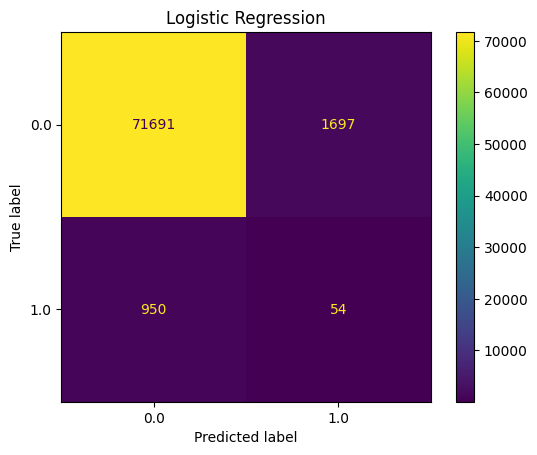

In [29]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Logistic Regression")
plt.show()

### Random Forest

In [30]:
def objective_rf(trial):
    if len(X_train) > OPTUNA_SAMPLE_SIZE:
        X_tune, _, y_tune, _ = train_test_split(
            X_train,
            y_train,
            train_size=OPTUNA_SAMPLE_SIZE,
            stratify=y_train,
            random_state=SEED,
        )
    else:
        X_tune = X_train
        y_tune = y_train

    X_fit, X_val, y_fit, y_val = train_test_split(
        X_tune,
        y_tune,
        test_size=OPTUNA_VALID_SIZE,
        stratify=y_tune,
        random_state=SEED,
    )

    class_weight = trial.suggest_categorical(
        "class_weight", [None, "balanced", "balanced_subsample"]
    )
    max_depth = trial.suggest_int("max_depth", 5, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=50),
        max_depth=max_depth,
        min_samples_split=trial.suggest_int("min_samples_split", 2, 25),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 15),
        max_features=max_features,
        class_weight=class_weight,
        n_jobs=-1,
        random_state=SEED,
    )

    rf.fit(X_fit, y_fit)
    y_score = rf.predict_proba(X_val)[:, 1]

    return roc_auc_score(y_val, y_score)


study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study_rf.optimize(objective_rf, n_trials=OPTUNA_N_TRIALS_RF, show_progress_bar=True)

rf = RandomForestClassifier(
    **study_rf.best_params,
    n_jobs=-1,
    random_state=SEED,
)

rf.fit(X_train, y_train)

study_rf.best_params

  0%|          | 0/15 [00:00<?, ?it/s]

{'class_weight': 'balanced_subsample',
 'max_depth': 10,
 'max_features': 'log2',
 'n_estimators': 450,
 'min_samples_split': 3,
 'min_samples_leaf': 15}

In [31]:
y_score_rf_train = rf.predict_proba(X_train)[:, 1]
THRESHOLD_RF = best_f1_threshold(y_train, y_score_rf_train)

y_score_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = predict_with_threshold(y_score_rf, THRESHOLD_RF)

print("RandomForest threshold:", THRESHOLD_RF)

RandomForest threshold: 0.5480434174426294


In [32]:
count_metrics(y_test, y_pred_rf, y_score_rf)

roc auc: 0.5915706145820598
average precision: 0.02521359160759242
balanced accuracy: 0.5129472571370375
f1: 0.04124926340601061


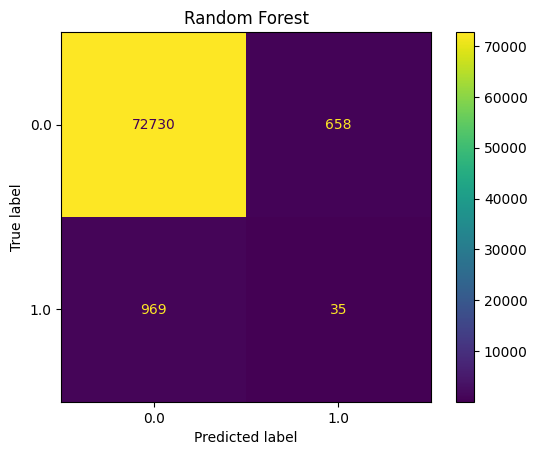

In [33]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest")
plt.show()

### Сравнение моделей

In [34]:
results_df = pd.DataFrame(
    [
        {
            "model": "always_zero",
            "roc_auc": roc_auc_score(y_test, y_pred_zeros),
            "average_precision": average_precision_score(y_test, y_pred_zeros),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_zeros),
            "f1": f1_score(y_test, y_pred_zeros, zero_division=0),
        },
        {
            "model": "random_by_prior",
            "roc_auc": roc_auc_score(y_test, y_pred_random),
            "average_precision": average_precision_score(y_test, y_pred_random),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_random),
            "f1": f1_score(y_test, y_pred_random, zero_division=0),
        },
        {
            "model": "logistic_regression",
            "roc_auc": roc_auc_score(y_test, y_score_lr),
            "average_precision": average_precision_score(y_test, y_score_lr),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_lr),
            "f1": f1_score(y_test, y_pred_lr, zero_division=0),
        },
        {
            "model": "random_forest",
            "roc_auc": roc_auc_score(y_test, y_score_rf),
            "average_precision": average_precision_score(y_test, y_score_rf),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
            "f1": f1_score(y_test, y_pred_rf, zero_division=0),
        },
    ]
)

results_df = results_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)
results_df.style.format(
    {
        "roc_auc": "{:.6f}",
        "average_precision": "{:.6f}",
        "balanced_accuracy": "{:.6f}",
        "f1": "{:.6f}",
    }
)

,model,roc_auc,average_precision,balanced_accuracy,f1
0,logistic_regression,0.628751,0.021954,0.515331,0.039201
1,random_forest,0.591571,0.025214,0.512947,0.041249
2,always_zero,0.500000,0.013496,0.500000,0.000000
3,random_by_prior,0.499163,0.013476,0.499163,0.011905


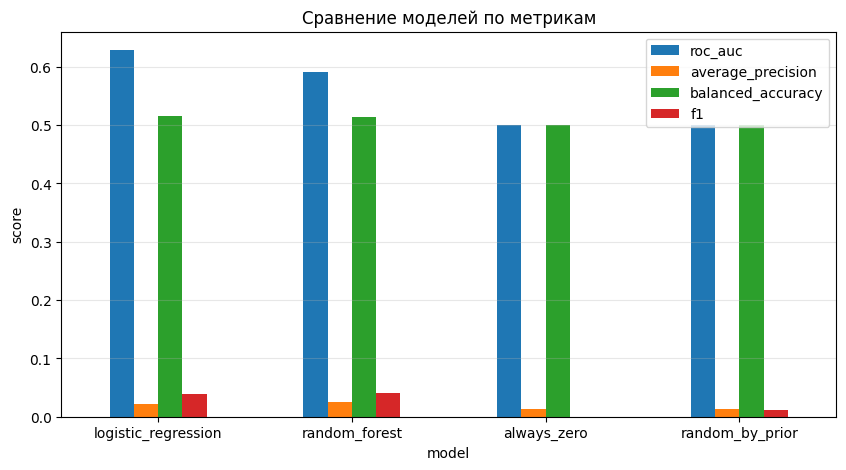

In [35]:
metrics_to_plot = ["roc_auc", "average_precision", "balanced_accuracy", "f1"]

results_df.set_index("model")[metrics_to_plot].plot(
    kind="bar", figsize=(10, 5), rot=0, title="Сравнение моделей по метрикам"
)

plt.ylabel("score")
plt.grid(axis="y", alpha=0.3)
plt.show()